In [1]:
import mlflow
import mlflow.sklearn
import joblib
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [2]:
import os
print(os.getcwd())

C:\Users\Akshay Gund\Projects\heart-disease-mlops\notebooks


In [3]:
import os

print("Data folder:")
print(os.listdir("../data"))

print("\nProcessed folder:")
print(os.listdir("../data/processed"))

Data folder:
['.gitkeep', 'processed', 'raw']

Processed folder:
['heart_processed.csv']


In [4]:
df = pd.read_csv("../data/processed/heart_processed.csv")
import joblib

# Load model
model = joblib.load("../artifacts/best_model.pkl")

# Load scaler
scaler = joblib.load("../artifacts/scaler.pkl")

print("Artifacts loaded successfully!")

Artifacts loaded successfully!


In [5]:
from sklearn.model_selection import train_test_split

X = df.drop("target", axis=1)
y = df["target"]

X = pd.get_dummies(
    X,
    columns=["cp", "restecg", "slope", "thal"],
    drop_first=True,
    dtype=int
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data prepared successfully!")

Data prepared successfully!


In [6]:
import mlflow

mlflow.set_tracking_uri("sqlite:///mlflow.db")

print("Tracking URI:", mlflow.get_tracking_uri())

Tracking URI: sqlite:///mlflow.db


In [7]:
with mlflow.start_run(run_name="RandomForest_HeartDisease"):
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    print("MLflow run started!")

MLflow run started!


C:\Users\Akshay Gund\Anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Akshay Gund\Anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [8]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC AUC  :", roc_auc)

Accuracy : 0.8524590163934426
Precision: 0.8518518518518519
Recall   : 0.8214285714285714
F1 Score : 0.8363636363636363
ROC AUC  : 0.9393939393939393


In [9]:
import mlflow.sklearn

with mlflow.start_run(run_name="RandomForest_Final"):

    # Parameters
    mlflow.log_param("Model", "RandomForest")
    mlflow.log_param("max_depth", 5)
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("min_samples_leaf", 1)
    mlflow.log_param("min_samples_split", 2)

    # Metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)

    # Save the model
    mlflow.sklearn.log_model(model, "random_forest_model")

    print("Everything logged successfully!")

2026/07/11 08:57:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Everything logged successfully!


In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")
plt.close()

In [11]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\Akshay Gund\Projects\heart-disease-mlops\notebooks
['.gitkeep', '.ipynb_checkpoints', '01_eda.ipynb', '02_preprocessing.ipynb', '03_model_training.ipynb', '04_mlflow_tracking.ipynb', 'confusion_matrix.png', 'mlflow.db', 'mlruns', 'roc_curve.png']


<Figure size 600x600 with 0 Axes>

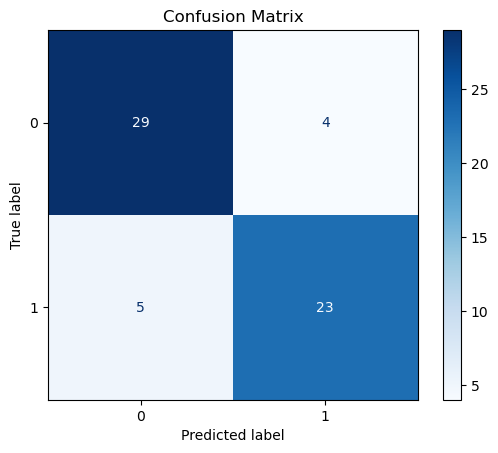

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(6,6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.savefig("../artifacts/confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

<Figure size 600x600 with 0 Axes>

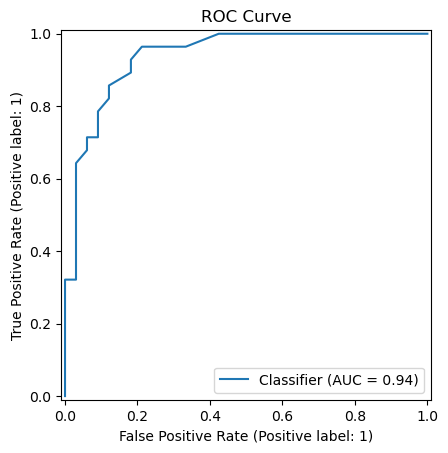

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(6,6))

RocCurveDisplay.from_predictions(y_test, y_prob)

plt.title("ROC Curve")

plt.savefig("../artifacts/roc_curve.png", dpi=300, bbox_inches="tight")

plt.show()

<Figure size 600x600 with 0 Axes>

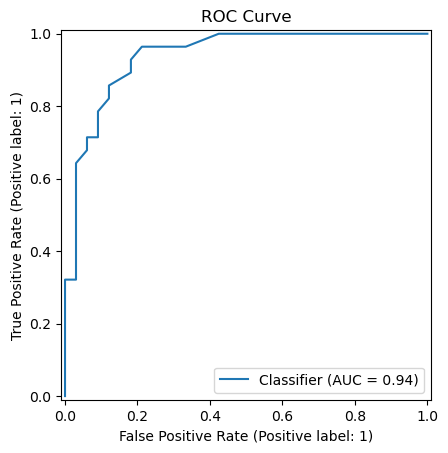

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(6,6))

RocCurveDisplay.from_predictions(y_test, y_prob)

plt.title("ROC Curve")

plt.savefig("roc_curve.png")

plt.show()

In [15]:
import os
print(os.listdir())

['.gitkeep', '.ipynb_checkpoints', '01_eda.ipynb', '02_preprocessing.ipynb', '03_model_training.ipynb', '04_mlflow_tracking.ipynb', 'confusion_matrix.png', 'mlflow.db', 'mlruns', 'roc_curve.png']


In [16]:
with mlflow.start_run(run_name="RandomForest_Artifacts"):

    mlflow.log_artifact("confusion_matrix.png")
    mlflow.log_artifact("roc_curve.png")

    print("Artifacts logged successfully!")

Artifacts logged successfully!


In [17]:
import mlflow

print("Tracking URI:", mlflow.get_tracking_uri())

Tracking URI: sqlite:///mlflow.db


In [18]:
import mlflow
import mlflow.sklearn

with mlflow.start_run(run_name="RandomForest_Final"):

    # Parameters
    mlflow.log_param("model", "RandomForest")
    mlflow.log_param("max_depth", 5)
    mlflow.log_param("n_estimators", 200)

    # Metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)

    # Model
    mlflow.sklearn.log_model(model, "model")

    # Artifacts
    mlflow.log_artifact("confusion_matrix.png")
    mlflow.log_artifact("roc_curve.png")

    print("Everything logged successfully!")

2026/07/11 08:58:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Everything logged successfully!
